## LightGBM vs XGBoost 비교 실습

In [3]:
# Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 모델
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [12]:
# 데이터 불러오기
housing = fetch_california_housing()

# 입력 데이터 (feature들)
X = pd.DataFrame(housing.data, columns=housing.feature_names)
# 정답 데이터 (집값)
y = pd.Series(housing.target)

In [5]:
# 데이터 분할
X_test, X_train, y_test, y_train = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [6]:
# 모델 정의
# XGBoost 모델
xgb_model = XGBRegressor(
    n_estimators=300,        # 트리 개수
    learning_rate=0.05,      # 학습 속도
    max_depth=5,             # 트리 깊이 (복잡도)
    subsample=0.8,           # 데이터 일부 사용 (과적합 방지)
    colsample_bytree=0.8,    # feature 일부 사용 (과적합 방지)
    random_state=42          # 결과 고정
)

# LightGBM 모델
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [7]:
# 모델 학습
# XGBoost 학습
xgb_model.fit(X_train, y_train)

# LightGBM 학습
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 4128, number of used features: 8
[LightGBM] [Info] Start training from score 2.055003


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [13]:
# 예측 수행
xgb_pred = xgb_model.predict(X_test)
lgb_pred = lgb_model.predict(X_test)

In [17]:
# 모델 성능 평가 함수 정의
def evaluate(y_train, y_pred):
    mae = mean_absolute_error(y_train, y_pred)          # MAE: 평균 절대 오차
    rmse = np.sqrt(mean_squared_error(y_train, y_pred)) # RMSE: 평균 제곱 오차의 루트
    r2 = r2_score(y_train, y_pred)                      # R2: 모델 설명력

    return mae, rmse, r2                                # 세 가지 성능 지표 반환

# 성능 계산
xgb_mae, xgb_rmse, xgb_r2 = evaluate(y_test, xgb_pred)  # XGBoost 성능
lgb_mae, lgb_rmse, lgb_r2 = evaluate(y_test, lgb_pred)  # LightGBM 성능

# 출력
print("========== XGBoost 성능 ==========")
print(f"MAE : {xgb_mae:.4f}")    # 소수점 4자리 출력
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R2 : {xgb_r2:.4f}")

print("========== LightGBM 성능 ==========")
print(f"MAE : {lgb_mae:.4f}")
print(f"RMSE : {lgb_rmse:.4f}")
print(f"R2 : {lgb_r2:.4f}")

========== XGBoost 성능 ==========
MAE : 0.3336
RMSE : 0.4913
R2 : 0.8194
========== LightGBM 성능 ==========
MAE : 0.3256
RMSE : 0.4835
R2 : 0.8251


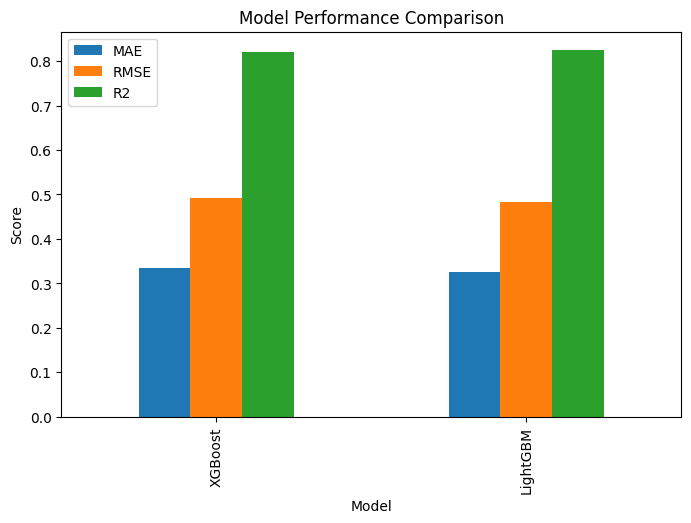

In [20]:
# 성능 비교 시각화
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],   # 모델 이름
    "MAE": [xgb_mae, lgb_mae],          # MAE 값
    "RMSE": [xgb_rmse, lgb_rmse],       # RMSE 값
    "R2": [xgb_r2, lgb_r2],             # R2 값
})

# 막대 그래프 시각화
# Model을 x축으로 설정 후, 각 성능 지표를 막대 그래프로 비교
results.set_index("Model").plot(kind="bar", figsize=(8,5))

plt.title("Model Performance Comparison")  # 그래프 제목
plt.ylabel("Score")                        # y축 이름
plt.show()                                 # 그래프 출력

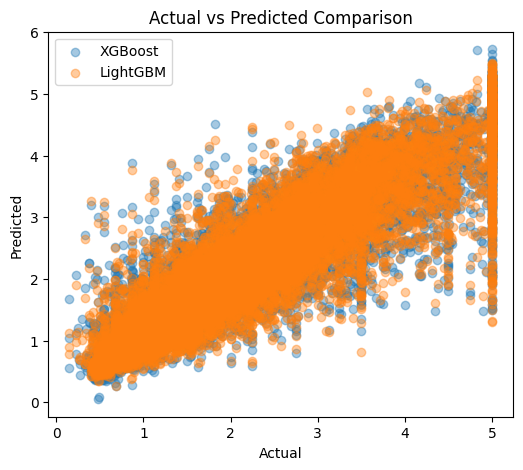

In [27]:
# 실제값 vs 예측값 성능 비교
plt.figure(figsize=(6,5))                      # 그래프 크기 설정

# XGBoost
# 실제값 vs 예측값 (alpha: 투명도, label: 범례 이름)
plt.scatter(y_test, xgb_pred, alpha=0.4, label="XGBoost")

# LightGBM
# 두 모델을 같은 그래프에 표시
plt.scatter(y_test, lgb_pred, alpha=0.4, label="LightGBM")

plt.xlabel("Actual")                           # x축: 실제값
plt.ylabel("Predicted")                        # y축: 예측값
plt.title("Actual vs Predicted Comparison")    # 그래프 제목

plt.legend()                                   # 범례 표시 (모델 구분)
plt.show()                                     # 그래프 출력

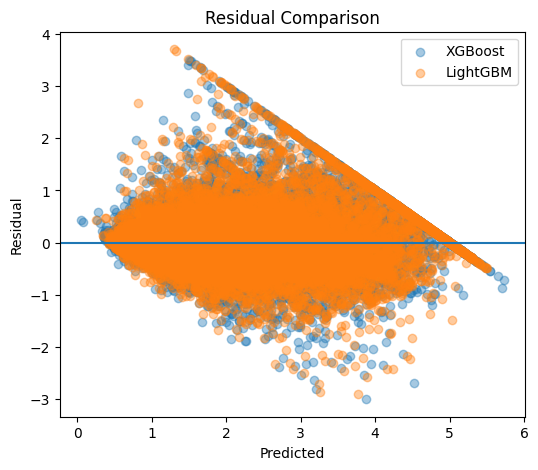

In [30]:
# 잔차 비교 (잔차(residual): 실제값 - 예측값)
xgb_residual = y_test - xgb_pred
lgb_residual = y_test - lgb_pred

plt.figure(figsize=(6,5))

# 예측값 vs 오차 (0에 가까울수록 좋음)
# XGBoost
plt.scatter(xgb_pred, xgb_residual, alpha=0.4, label="XGBoost")  

# LightGBM
plt.scatter(lgb_pred, lgb_residual, alpha=0.4, label="LightGBM")  

# 두 모델 오차 비교
plt.axhline(0)                    # 기준선 (오차 0 → 완벽한 예측)
plt.xlabel("Predicted")           # x축: 예측값
plt.ylabel("Residual")            # y축: 오차
plt.title("Residual Comparison")

plt.legend()
plt.show()

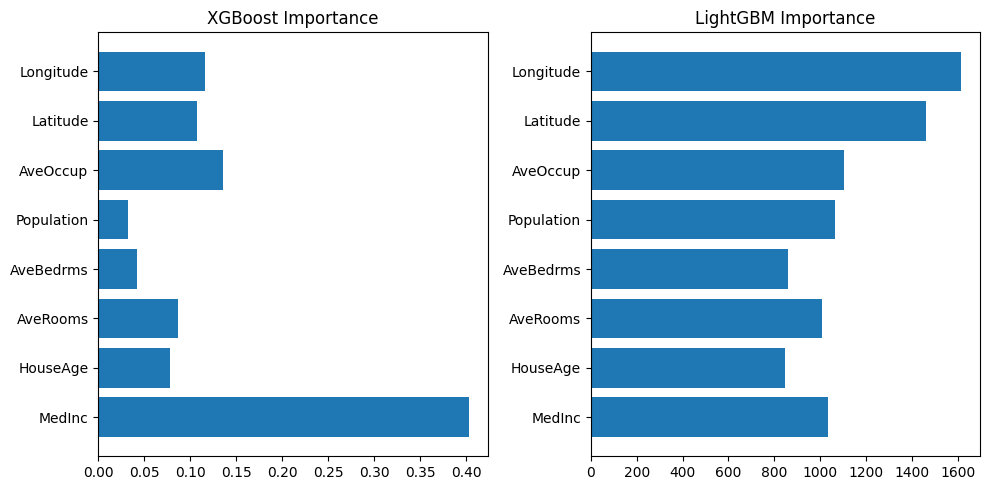

In [29]:
# feature importance 비교

# XGBoost 중요도
xgb_importance = xgb_model.feature_importances_

# LightGBM 중요도
lgb_importance = lgb_model.feature_importances_

# 그래프
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)                      # 1행 2열 중 첫 번째 그래프
plt.barh(X.columns, xgb_importance)
plt.title("XGBoost Importance")

plt.subplot(1,2,2)                      # 두 번째 그래프
plt.barh(X.columns, lgb_importance)
plt.title("LightGBM Importance")

plt.tight_layout()                      # 그래프 간격 자동 조정
plt.show()